# ArgosQC WildlifeComputers Project Config


1. Connect to WildlifeComputers portal (requires access_key and secret_key pair)
2. Show a list of collaborator (tag owner) who shared projects with OTN.
3. Show/download selected raw tag data from WC portal. 
4. Map tag locations for observation.
5. Generate configuration files for ArgosQC.wc_qc().

In [2]:
from py_nrt import argos_wc_project_config as awpc
import itables

## 1. Connects to WildlifeComputers portal

### OTN data team for `access_key` (Access Key) and `secret_key` (Secret Key) for OTNDC account.

In [ ]:
# Ask OTN DC for the keys.
access_key = ""
secret_key = ""

# Destination folder for wc_qc config files and tag downloads.
input_path = r'input'

# Set to True to see API payload and response.
verbose=False

## 2. Show a list of collaborator (tag owner) who shared projects with OTN

### Contact OTN data team if your collaborator is not in the list.

In [ ]:
# Get all collaborators
collaborators_df, collaborator_id_widget = awpc.wc_get_collab_ids(a_key=access_key, s_key=secret_key, verbose=verbose)

## 3. Show/download selected raw tag data from WC portal

### The goal of this cell is to identify a list of WC `tag_uuid`s in an OTN project:

#### 3.1 Find the project and WC tags in `otn_satellite_tags` table in OTN Node DB e.g.  

#### 3.2 Column mapping between  `otn_satellite_tags` table and tag information from WC portal.

`collectornumber` - `serial_number`

`ptt_code` - `ptt`

`instrumentmodel` - `tag_type`

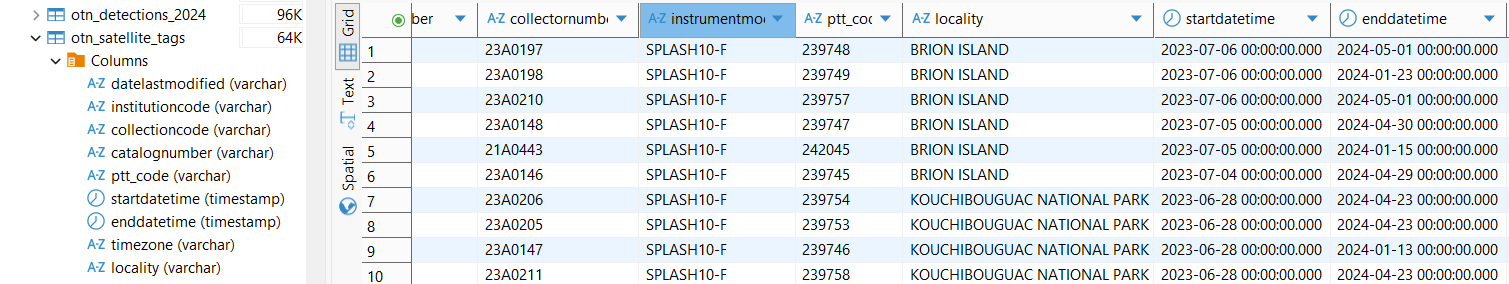

### 3.3 Take note of the list of WC `tag_uuid`s 

In [ ]:
if collaborator_id_widget.value:
    deployment_df = awpc.get_deployments_for_owner_id(
        a_key=access_key, 
        s_key=secret_key, 
        collaborator=collaborator_id_widget.value, 
        verbose=verbose
    )
else:
    print('Please select a collaborator...')

## (Optional) Download Selected Tag for Observation
### Note: ptt is reusable; tag UUID is the uinque identifier

In [ ]:
awpc.download_tag(
    a_key=access_key, 
    s_key=secret_key, 
    deployment_df=deployment_df, 
    verbose=verbose
)

## 5. Generate WC_QC Configuration Files

#### `time_step` (hours): adjust value (usually between 1 to 10) according to tagged animal's species.
#### `collection_code`: if project is found in OTN. Otherwise leave it blank.
#### `common_name` and `species` (scientific name): source 


In [ ]:
# Default settings
program = 'irap'

time_step = 3

# Project specific settings
collection_code = 'vmlppws'
common_name = 'grey seal'
species = 'Halichoerus grypus'
release_site = 'BRION ISLAND'
state_country = 'Canada'

tag_uuid_list = ['5f90d1ad17e84815885608c1', '60085a1517e84815e4b95f34']

awpc.create_wc_qc_config(
    dest_path=input_path,
    a_key=access_key, 
    s_key=secret_key, 
    collaborator=collaborator_id_widget.value,
    program = program,
    project_id = collection_code,
    time_step=time_step,
    common_name=common_name,
    species=species,
    release_site=release_site,
    state_country=state_country,
    tag_uuid_list=tag_uuid_list
)


## 4. Map locations from PI and compare with WC downloaded ones.

In [ ]:
from keplergl import KeplerGl
import pandas as pd

data = pd.DataFrame({
    'lat': [51.5074, 40.7128, 35.6762, -33.8688],
    'lng': [-0.1278, -74.0060, 139.6503, 151.2093],
    'name': ['London', 'New York', 'Tokyo', 'Sydney'],
    'value': [100, 200, 150, 80]
})

# Create map
map_2 = KeplerGl(height=600, data={'locations': data})
map_2.config['mapboxApiAccessToken'] = ''

# # Add some custom configuration
# map_2.config['visState']['layers'][0]['config']['radius'] = 50
# map_2.config['visState']['layers'][0]['config']['color'] = [255, 0, 0]

map_2  # Display the map


## Test if KeplerGl is Installed and Enabled
- Expected output


- Otherwise stop jupyter notebook and run below command in conda consule: 

```
jupyter contrib nbextension install --sys-prefix

jupyter nbextension install --py --sys-prefix keplergl
jupyter nbextension enable --py --sys-prefix keplergl
jupyter nbextension enable --py --sys-prefix widgetsnbextension

```

![image.png](attachment:image.png)



In [3]:
from keplergl import KeplerGl
KeplerGl()


C:\Users\hpz2\.conda\envs\rt-sat-to-obis\Lib\site-packages\keplergl\keplergl.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_string


User Guide: https://docs.kepler.gl/docs/keplergl-jupyter


C:\Users\hpz2\.conda\envs\rt-sat-to-obis\Lib\site-packages\IPython\core\formatters.py:367: FormatterWarning: text/html formatter returned invalid type <class 'bytes'> (expected <class 'str'>) for object: KeplerGl()
  warnings.warn(


KeplerGl()